# E47 · Weather jiu-jitsu on the butterfly: Bayesian assimilation and regime control of Lorenz-63

| | |
|---|---|
| **Type** | Advanced worked example - read, run, modify |
| **Data** | Simulated: the **Lorenz (1963)** convection model with process noise, observed every 0.05 time units with multiplicative (state-dependent) measurement error - the setting of Liu, Huang & Lall (2026), *Chaos, Solitons & Fractals* 210, 118657, "Targeted adaptive chaos control of regimes and eddy strength in two Lorenz models" |
| **You will learn** | The Lorenz attractor as a two-**regime** system (the butterfly's wings) and how long it stays in each · the **local (instantaneous) Lyapunov exponent** (largest eigenvalue of the symmetric part of the Jacobian), what it does and does not predict, and how it differs from the **finite-time** exponent · **Bayesian data assimilation**: recovering $\sigma, \rho, \beta$ and the whole path from noisy observations with a centred latent-state model and RK4 inside PyMC (the E46 lesson applied to an ODE) · **ensemble forecasts of regime switches** from the posterior · **minimal-energy control** of the regime: a linear-response nudge computed from the tangent propagator, and why chaos makes the nudge small · a **controlled experiment** the paper does not run: trigger rules (local Lyapunov exponent, a geometric rule, plan every step, no control) across nudge budgets, and what uncertainty in the state and the parameters does to the controller |

## The idea, in one paragraph

Liu, Huang & Lall call it **weather jiu-jitsu**: instead of fighting the atmosphere, use its
own instability. A chaotic system amplifies small differences, so a *small* push at the right
moment can redirect it a long way - away from a heat dome, a blocking pattern, a storm track.
Their test bed is the Lorenz-63 model, whose trajectory jumps unpredictably between two
"wings" (two weather regimes); the goal is to keep it on one wing with the least possible
control effort, acting only when a local instability indicator says the moment is right. This
notebook rebuilds that experiment the Bayesian way. We do not assume the controller knows the
model: it learns the parameters and the current state from noisy observations, and it plans
with the whole posterior. Then we test which parts of the recipe actually matter.

## The plan

1. The butterfly: two regimes, residence times and local instability
2. Learning the model from noisy observations
3. Forecasting a regime switch
4. A minimal-energy nudge, and why chaos makes it small
5. What matters: trigger rules, budgets and uncertainty

In [1]:
import logging
import time

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pymc as pm
import pytensor
import pytensor.tensor as pt

RANDOM_SEED = 47
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-variat")
logging.getLogger("pymc").setLevel(logging.WARNING)
BLUE, ORANGE, AQUA, GREY, PURPLE, RED, INK = (
    "#2a78d6", "#eb6834", "#1baf7a", "#8a8a86", "#8c5ac8", "#c8384e", "#222222")
print(f"PyMC {pm.__version__}, ArviZ {az.__version__}, PyTensor {pytensor.__version__}")

PyMC 6.3.2, ArviZ 1.3.0, PyTensor 3.3.2


## 1 · The butterfly: two regimes, residence times and local instability

Lorenz (1963) reduced a model of convection in a layer of fluid heated from below to three
variables: $x$ is the intensity of the convective roll, $y$ and $z$ describe the temperature
differences.

$$\dot x = \sigma (y - x), \qquad \dot y = x(\rho - z) - y, \qquad \dot z = x y - \beta z,$$

with the classic values $\sigma = 10$, $\rho = 28$, $\beta = 8/3$. The two wings of the
attractor are circulations turning one way ($x > 0$) or the other ($x < 0$); think of them as
two weather regimes. As in the paper we integrate with fourth-order Runge-Kutta (RK4) and
$\Delta t = 0.01$, and every function below works on a whole batch of states and parameter
vectors at once.

In [2]:
DT = 0.01
THETA_TRUE = np.array([10.0, 28.0, 8.0 / 3.0])


def lorenz(s, th):
    """Lorenz-63 vector field; s (..., 3), th (..., 3) = (sigma, rho, beta)."""
    sg, rh, be = th[..., 0], th[..., 1], th[..., 2]
    x, y, z = s[..., 0], s[..., 1], s[..., 2]
    return np.stack([sg * (y - x), x * (rh - z) - y, x * y - be * z], axis=-1)


def jacobian(s, th):
    sg, rh, be = th[..., 0], th[..., 1], th[..., 2]
    x, y, z = s[..., 0], s[..., 1], s[..., 2]
    o = np.zeros_like(x)
    return np.stack([np.stack([-sg, sg, o], -1),
                     np.stack([rh - z, o - 1, -x], -1),
                     np.stack([y, x, o - be], -1)], -2)


def rk4(s, th, dt=DT):
    k1 = lorenz(s, th)
    k2 = lorenz(s + dt / 2 * k1, th)
    k3 = lorenz(s + dt / 2 * k2, th)
    k4 = lorenz(s + dt * k3, th)
    return s + dt / 6 * (k1 + 2 * k2 + 2 * k3 + k4)


def local_lyapunov(s, th=THETA_TRUE):
    """Instantaneous LLE: largest eigenvalue of the symmetric part of the Jacobian."""
    J = jacobian(s, np.broadcast_to(th, np.shape(s)))
    return np.linalg.eigvalsh(0.5 * (J + np.swapaxes(J, -1, -2)))[..., -1]


# A long free run on the attractor
s = np.array([1.0, 1.0, 1.0])
for _ in range(2000):
    s = rk4(s, THETA_TRUE)
n_long = 100_000
path = np.empty((n_long, 3))
for t in range(n_long):
    s = rk4(s, THETA_TRUE)
    path[t] = s
wing = np.sign(path[:, 0])
switch_idx = np.flatnonzero(np.diff(wing) != 0)
residence = np.diff(switch_idx) * DT
lle_path = local_lyapunov(path)
print(f"{len(switch_idx)} regime switches in {n_long * DT:.0f} time units; residence time "
      f"median {np.median(residence):.2f}, 90th percentile {np.quantile(residence, 0.9):.2f}, "
      f"max {residence.max():.1f}")
print(f"instantaneous LLE > 0 at {np.mean(lle_path > 0):.0%} of attractor points "
      f"(median {np.median(lle_path):.1f}, range {lle_path.min():.1f} to {lle_path.max():.1f})")

546 regime switches in 1000 time units; residence time median 1.54, 90th percentile 3.61, max 10.6
instantaneous LLE > 0 at 87% of attractor points (median 4.5, range -1.0 to 13.1)


The **instantaneous (local) Lyapunov exponent** used by Liu et al. is the largest eigenvalue of
the symmetric part of the Jacobian, $S = (J + J^\top)/2$: the fastest rate at which an
infinitesimal ball of states is being stretched *right now*. It is cheap and local, but it is
not the same thing as the classical exponent (a long-run average of stretching along the
path) or the **finite-time** exponent (the actual growth of a perturbation over the next
stretch of time $\tau$). Below we compare the two over $\tau = 0.5$ time units, and ask the
question behind the whole control strategy: does a high local exponent now announce a regime
switch soon?

correlation of instantaneous LLE with the 0.5-unit finite-time exponent: -0.26


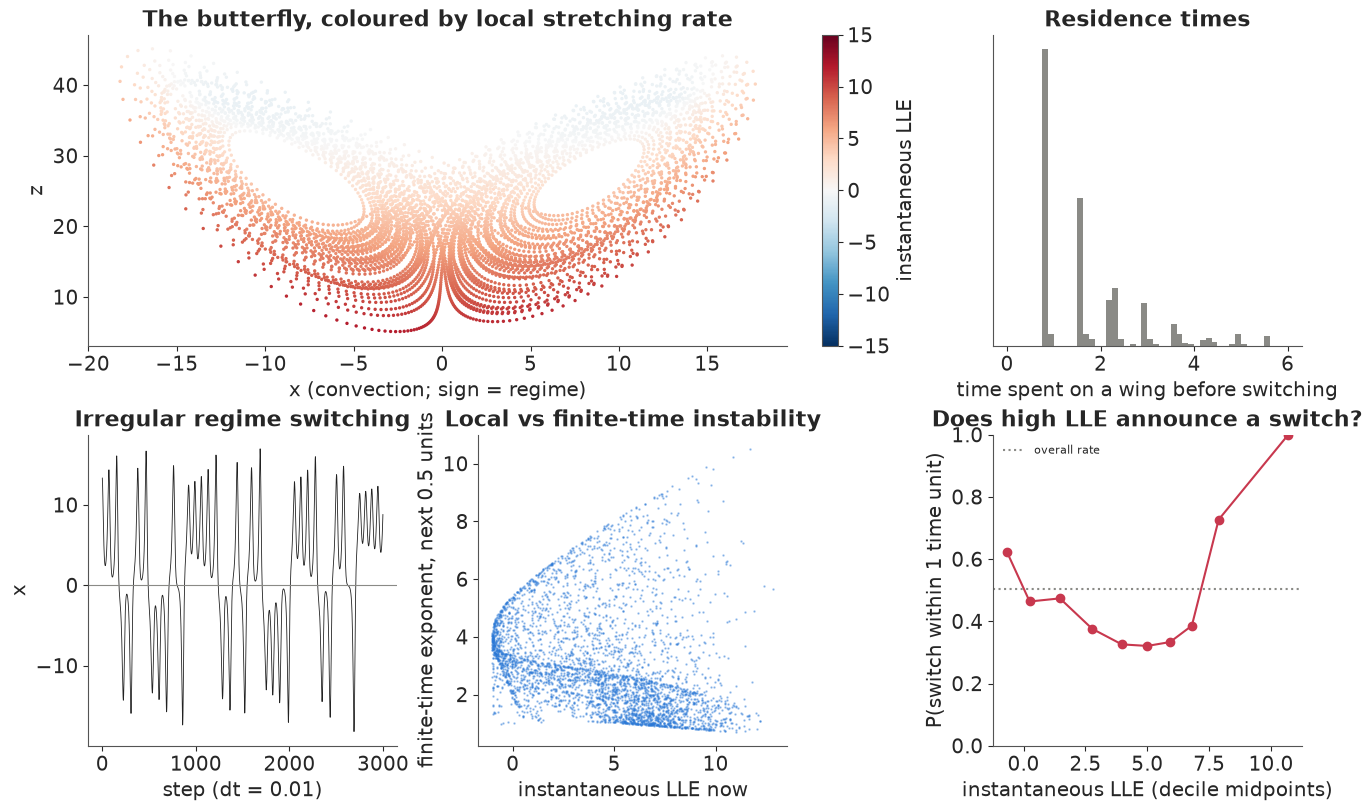

In [3]:
def finite_time_lyapunov(s0, th, horizon):
    """Largest finite-time exponent over `horizon` steps, via the tangent propagator (batched)."""
    s, M = s0.copy(), np.broadcast_to(np.eye(3), s0.shape[:-1] + (3, 3)).copy()
    th = np.broadcast_to(th, s0.shape)
    for _ in range(horizon):
        M = M + DT * jacobian(s, th) @ M          # Euler tangent step; adequate at dt = 0.01
        s = rk4(s, th)
    return np.log(np.linalg.svd(M, compute_uv=False)[..., 0]) / (horizon * DT)


sub_idx = np.arange(0, n_long - 200, 25)
ftle = finite_time_lyapunov(path[sub_idx], THETA_TRUE, 50)
# Does the regime switch within the next 1 time unit?
next_switch = np.searchsorted(switch_idx, sub_idx)
steps_to_switch = np.where(next_switch < len(switch_idx),
                           switch_idx[np.minimum(next_switch, len(switch_idx) - 1)] - sub_idx, 10**9)
switch_soon = steps_to_switch <= 100
bins = np.quantile(lle_path[sub_idx], np.linspace(0, 1, 11))
bin_of = np.clip(np.digitize(lle_path[sub_idx], bins) - 1, 0, 9)
p_switch = np.array([switch_soon[bin_of == b].mean() for b in range(10)])
bin_mid = 0.5 * (bins[1:] + bins[:-1])
print(f"correlation of instantaneous LLE with the 0.5-unit finite-time exponent: "
      f"{np.corrcoef(lle_path[sub_idx], ftle)[0, 1]:.2f}")

fig = plt.figure(figsize=(13, 8))
gs = fig.add_gridspec(2, 3)
ax = fig.add_subplot(gs[0, :2])
show = slice(0, 6000)
sc = ax.scatter(path[show, 0], path[show, 2], c=lle_path[show], s=2, cmap="RdBu_r",
                vmin=-15, vmax=15)
fig.colorbar(sc, ax=ax, label="instantaneous LLE")
ax.set(xlabel="x (convection; sign = regime)", ylabel="z",
       title="The butterfly, coloured by local stretching rate")
ax = fig.add_subplot(gs[0, 2])
ax.hist(residence, bins=np.linspace(0, 6, 49), color=GREY)
ax.set(xlabel="time spent on a wing before switching", yticks=[], title="Residence times")
ax = fig.add_subplot(gs[1, 0])
ax.plot(path[:3000, 0], color=INK, lw=0.6)
ax.axhline(0, color=GREY, lw=0.8)
ax.set(xlabel="step (dt = 0.01)", ylabel="x", title="Irregular regime switching")
ax = fig.add_subplot(gs[1, 1])
ax.plot(lle_path[sub_idx], ftle, ".", color=BLUE, ms=1.5, alpha=0.4)
ax.set(xlabel="instantaneous LLE now", ylabel="finite-time exponent, next 0.5 units",
       title="Local vs finite-time instability")
ax = fig.add_subplot(gs[1, 2])
ax.plot(bin_mid, p_switch, "o-", color=RED)
ax.axhline(switch_soon.mean(), color=GREY, ls=":", label="overall rate")
ax.set(xlabel="instantaneous LLE (decile midpoints)", ylabel="P(switch within 1 time unit)",
       ylim=(0, 1), title="Does high LLE announce a switch?")
ax.legend(fontsize=8);

Three things to take from this figure before we control anything.

- **Switching is irregular**: the trajectory stays on a wing for anything from a fraction of a
  time unit to several, and the residence times have a long tail.
- **The instantaneous LLE is positive most of the time** with the exact Jacobian (87% of the
  attractor), and it is largest along the bottom of the butterfly (low $z$, small $|x|$), the
  route by which the trajectory passes from one wing towards the other. As a trigger with
  threshold 0 it fires at most steps.
- **It measures stretching now, not over the planning horizon.** Its correlation with the growth
  that perturbations actually experience over the next half time unit is *negative* (-0.26):
  where the flow is stretched hardest now, it is often about to be folded back.
- **Its top deciles do flag switches** - the probability of a switch within one time unit rises
  to 0.7-1.0 there - but largely because those points lie on the way between the wings, when a
  switch may already be under way. The middle deciles are *below* the average switch rate.
  Section 5 tests what this means for control.

## 2 · Learning the model from noisy observations

A controller for the real atmosphere does not know the equations' constants exactly, nor the
current state: it has a model with uncertain parameters and noisy observations. We simulate
that setting. The "true" system has **process noise** (small random kicks, 0.05 per
observation interval, standing in for everything the three equations leave out) and we observe
all three variables every 0.05 time units (5 RK4 steps) for 5 time units, with **multiplicative**
measurement error (5% of the value, plus a floor of 0.1), as in the paper's noise model.

In [4]:
EVERY, N_OBS, Q_TRUE, OBS_REL, OBS_ABS = 5, 100, 0.05, 0.05, 0.1
sim_rng = np.random.default_rng(1)
s = np.array([1.0, 1.0, 1.0])
for _ in range(1000):
    s = rk4(s, THETA_TRUE)
truth = [s]
for k in range(N_OBS - 1):
    for _ in range(EVERY):
        s = rk4(s, THETA_TRUE)
    s = s + Q_TRUE * sim_rng.standard_normal(3)
    truth.append(s)
truth = np.array(truth)
obs = truth * (1 + OBS_REL * sim_rng.standard_normal(truth.shape)) + OBS_ABS * sim_rng.standard_normal(truth.shape)
t_obs = np.arange(N_OBS) * EVERY * DT
print(f"{N_OBS} observations over {t_obs[-1]:.2f} time units; "
      f"{int(np.sum(np.diff(np.sign(truth[:, 0])) != 0))} regime switches in the window")

100 observations over 4.95 time units; 2 regime switches in the window


E46 showed that fitting a chaotic model by simulating one long path from its initial state
(trajectory matching) produces a likelihood with thousands of spikes. The cure carries over to
an ODE: make the **states at the observation times** the sampler's coordinates, integrate only
from one observation time to the next (5 RK4 steps, written in PyTensor and applied to all 99
intervals at once - this is **multiple shooting**), and let a model-error term $q$ absorb
the mismatch:

$$s_{k+1} \sim N\big(\Phi_\theta(s_k),\ q^2 I\big), \qquad
  y_k \sim N\big(s_k,\ (0.05\,|s_k| + 0.1)^2\big),$$

where $\Phi_\theta$ is the RK4 flow over one observation interval. Priors are log-normal
around order-of-magnitude guesses, half an order of magnitude wide: $\sigma \sim$
LogNormal(log 10, 0.5), $\rho \sim$ LogNormal(log 30, 0.5), $\beta \sim$ LogNormal(log 3, 0.5).
For $q$ a log-normal prior centred at 0.05 keeps the sampler out of the funnel at $q \to 0$
(where 300 states would have to line up exactly with a deterministic path); with a half-normal
prior the first attempt at this model had divergences and poor mixing of $q$.

In [5]:
def lorenz_pt(s, sg, rh, be):
    x, y, z = s[:, 0], s[:, 1], s[:, 2]
    return pt.stack([sg * (y - x), x * (rh - z) - y, x * y - be * z], axis=1)


with pm.Model() as assim_model:
    sigma = pm.LogNormal("sigma", np.log(10), 0.5)
    rho = pm.LogNormal("rho", np.log(30), 0.5)
    beta = pm.LogNormal("beta", np.log(3), 0.5)
    q = pm.LogNormal("q", np.log(0.05), 0.7)
    S = pm.Flat("S", shape=(N_OBS, 3))                   # the latent states at observation times
    flow = S[:-1]
    for _ in range(EVERY):                               # 5 RK4 steps, all intervals in parallel
        k1 = lorenz_pt(flow, sigma, rho, beta)
        k2 = lorenz_pt(flow + DT / 2 * k1, sigma, rho, beta)
        k3 = lorenz_pt(flow + DT / 2 * k2, sigma, rho, beta)
        k4 = lorenz_pt(flow + DT * k3, sigma, rho, beta)
        flow = flow + DT / 6 * (k1 + 2 * k2 + 2 * k3 + k4)
    pm.Potential("process", pm.logp(pm.Normal.dist(flow, q), S[1:]).sum())
    pm.Normal("y", S, OBS_REL * pt.abs(S) + OBS_ABS, observed=obs)

t0 = time.time()
with assim_model:
    idata = pm.sample(tune=2000, draws=2000, random_seed=RANDOM_SEED, progressbar=False, initvals={"S": obs},
                      nuts={"adaptation": "low_rank"})
print(f"{time.time() - t0:.0f} s, {int(idata.sample_stats['diverging'].sum())} divergences")
summ = az.summary(idata, var_names=["sigma", "rho", "beta", "q"], round_to=4)
summ["truth"] = [*THETA_TRUE, Q_TRUE]
print(summ[["mean", "sd", "eti89_lb", "eti89_ub", "ess_bulk", "r_hat", "truth"]])

100 s, 0 divergences
          mean      sd  eti89_lb  eti89_ub   ess_bulk   r_hat      truth
sigma  10.0264  0.0999    9.8718   10.1860  2848.9667  1.0009  10.000000
rho    27.9494  0.0939   27.7937   28.0929   643.2720  1.0102  28.000000
beta    2.6799  0.0147    2.6570    2.7033  3628.9819  1.0030   2.666667
q       0.0281  0.0124    0.0079    0.0492    16.9099  1.1723   0.050000


The three physical constants are recovered to within about half a per cent, from five
time units of noisy data: chaos makes the states hard to predict, but it makes the
*parameters* very well determined, because the path explores many different parts of the
attractor and each one tests the equations differently; all three 89% intervals contain the
truth. The model-error scale
$q$ is the hard part, and its sampling is **not** trustworthy: ESS below 20 and $\hat R$ about
1.17 even with 2,000 tuning steps. Its posterior (roughly 0.01-0.05) sits below the true 0.05.
With measurement error of 5% on values of order 10, the data can hardly tell small random kicks
from measurement error, and the 300 latent states couple to $q$ in a funnel. The physical
parameters and the states, which is what the controller uses, are well sampled; for $q$ a
stronger prior or more data would be needed. Next, the latent path:

RMS error: observations 0.897, posterior mean of the states 0.095


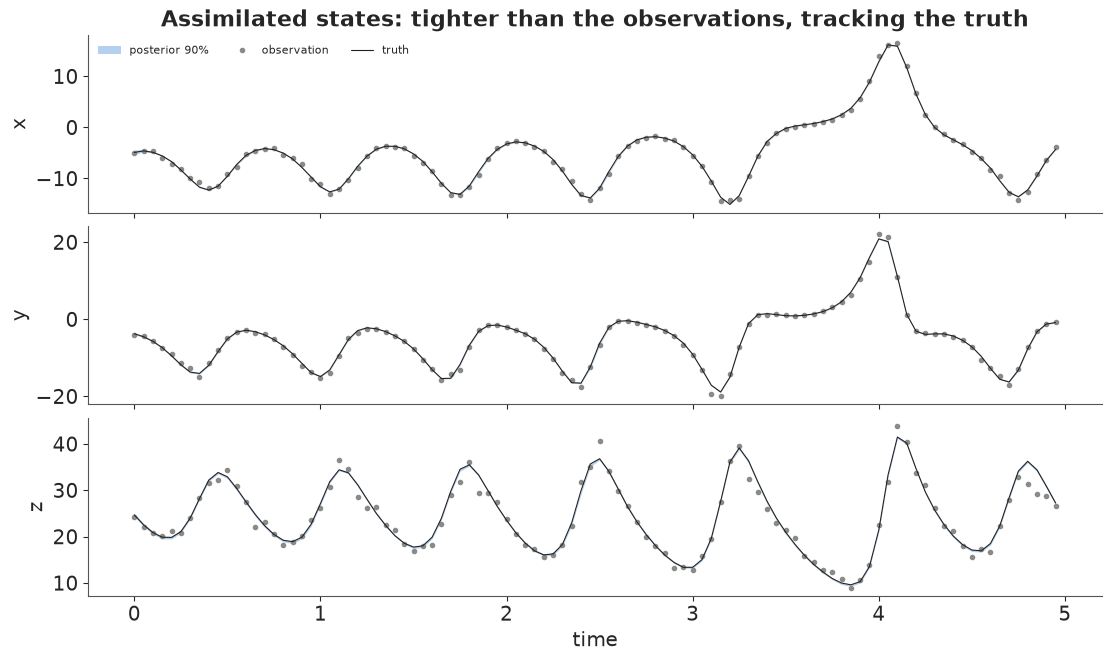

In [6]:
S_draws = idata.posterior["S"].stack(sample=("chain", "draw")).transpose("sample", ...).to_numpy()
theta_post = np.stack([idata.posterior[v].stack(sample=("chain", "draw")).to_numpy()
                       for v in ["sigma", "rho", "beta"]], axis=1)
fig, axes = plt.subplots(3, 1, figsize=(11, 6.5), sharex=True)
for i, (ax, name) in enumerate(zip(axes, "xyz")):
    lo, hi = np.quantile(S_draws[:, :, i], [0.05, 0.95], axis=0)
    ax.fill_between(t_obs, lo, hi, color=BLUE, alpha=0.35, lw=0, label="posterior 90%")
    ax.plot(t_obs, obs[:, i], "o", color=GREY, ms=3, label="observation")
    ax.plot(t_obs, truth[:, i], "-", color=INK, lw=0.8, label="truth")
    ax.set_ylabel(name)
axes[0].legend(fontsize=8, ncols=3)
axes[-1].set_xlabel("time")
axes[0].set_title("Assimilated states: tighter than the observations, tracking the truth");
err_obs = np.sqrt(np.mean((obs - truth) ** 2))
err_post = np.sqrt(np.mean((S_draws.mean(0) - truth) ** 2))
print(f"RMS error: observations {err_obs:.3f}, posterior mean of the states {err_post:.3f}")

## 3 · Forecasting a regime switch

With a posterior over the parameters and the current state, a forecast is an **ensemble**: run
each posterior draw forward (with process noise at the estimated $q$) and count the members that
end up on each wing. We forecast from the last observation and compare with what the true system
does next.

the ensemble first becomes undecided (10-90%) about the wing at lead 1.59 time units


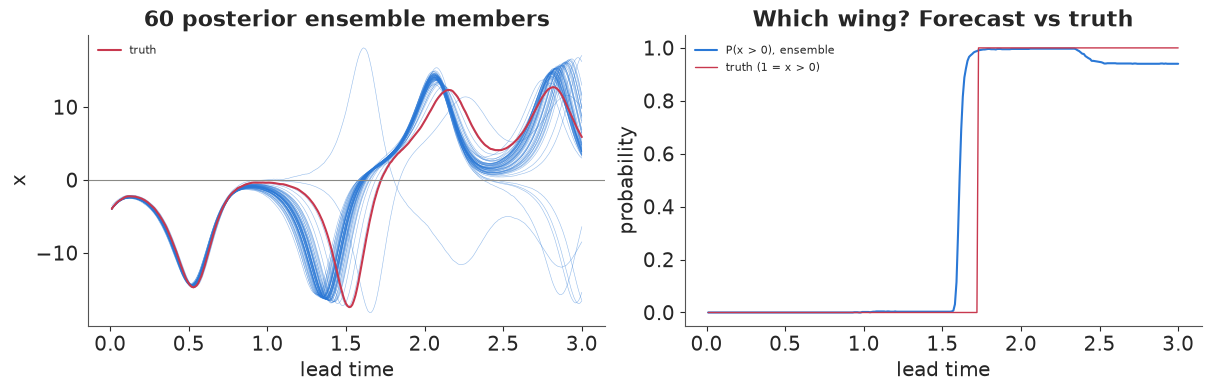

In [7]:
n_ens, lead_steps = 1000, 300
pick = rng.choice(len(theta_post), n_ens, replace=False)
ens_state, ens_theta = S_draws[pick, -1].copy(), theta_post[pick]
q_post = idata.posterior["q"].stack(sample=("chain", "draw")).to_numpy()[pick]
ens_x = np.empty((lead_steps, n_ens))
true_future = np.empty((lead_steps, 3))
s_true = truth[-1].copy()
fut_rng = np.random.default_rng(2)
for t in range(lead_steps):
    ens_state = rk4(ens_state, ens_theta)
    ens_state += (q_post / np.sqrt(EVERY))[:, None] * fut_rng.standard_normal(ens_state.shape)
    s_true = rk4(s_true, THETA_TRUE) + Q_TRUE / np.sqrt(EVERY) * fut_rng.standard_normal(3)
    ens_x[t], true_future[t] = ens_state[:, 0], s_true
lead = np.arange(1, lead_steps + 1) * DT
p_right = (ens_x > 0).mean(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
ax = axes[0]
for i in range(60):
    ax.plot(lead, ens_x[:, i], color=BLUE, lw=0.4, alpha=0.5)
ax.plot(lead, true_future[:, 0], color=RED, lw=1.5, label="truth")
ax.axhline(0, color=GREY, lw=0.8)
ax.set(xlabel="lead time", ylabel="x", title="60 posterior ensemble members")
ax.legend(fontsize=8)
ax = axes[1]
ax.plot(lead, p_right, color=BLUE, label="P(x > 0), ensemble")
ax.plot(lead, (true_future[:, 0] > 0).astype(float), color=RED, lw=1, label="truth (1 = x > 0)")
ax.set(xlabel="lead time", ylabel="probability", ylim=(-0.05, 1.05), title="Which wing? Forecast vs truth")
ax.legend(fontsize=8);
first_split = lead[np.argmax((p_right > 0.1) & (p_right < 0.9))]
print(f"the ensemble first becomes undecided (10-90%) about the wing at lead {first_split:.2f} time units")

For a while every member agrees; then the ensemble splits between the wings and the forecast
becomes a probability. The lead time at which that happens depends on where on the attractor we
start (near the centre of the butterfly it comes quickly), which is the practical meaning of
local instability. It also sets what a controller can do: to steer a regime switch it has to
act before the ensemble splits, while a small nudge still decides which way it goes.

## 4 · A minimal-energy nudge, and why chaos makes it small

The paper's controller solves a constrained optimisation (SLSQP) at each triggered step. We use
a transparent equivalent that is fast enough to run many experiments. The goal is to keep the
trajectory on the right wing: $x_h \ge 1$ over a planning horizon of $H = 30$ steps (0.3 time
units). At a planning step, the controller

1. forecasts an **ensemble** of 20 members (parameters from the posterior, and, when the state is
   observed with error, states drawn from the measurement-error distribution);
2. finds the step $h^*$ at which the ensemble's 10% quantile of $x_h$ is lowest; if it is above
   1, it does nothing;
3. otherwise computes the **sensitivity** $g = \partial x_{h^*} / \partial s_0$ with the tangent
   propagator (the same product of Jacobians as the finite-time exponent) and applies the
   smallest nudge that fixes the deficit to first order,
   $u = \text{deficit} \cdot g / \lVert g \rVert^2$ (repeated up to 3 times, capped at
   $\lVert u \rVert \le u_{\max}$).

Step 3 is the whole jiu-jitsu argument in one formula: **the required nudge is inversely
proportional to the sensitivity**, and in a chaotic system the sensitivity to the present state
grows exponentially with the horizon. The simulations below run many independent trials at once
(one row per trial), with process noise of 1% of the state per step, as in the paper's
multiplicative noise.

demo: 2.8 s; stayed on the right wing: True; nudges applied at 238 of 2000 steps (planned at 1700); median nudge size 0.266; control energy / system energy 0.0027%


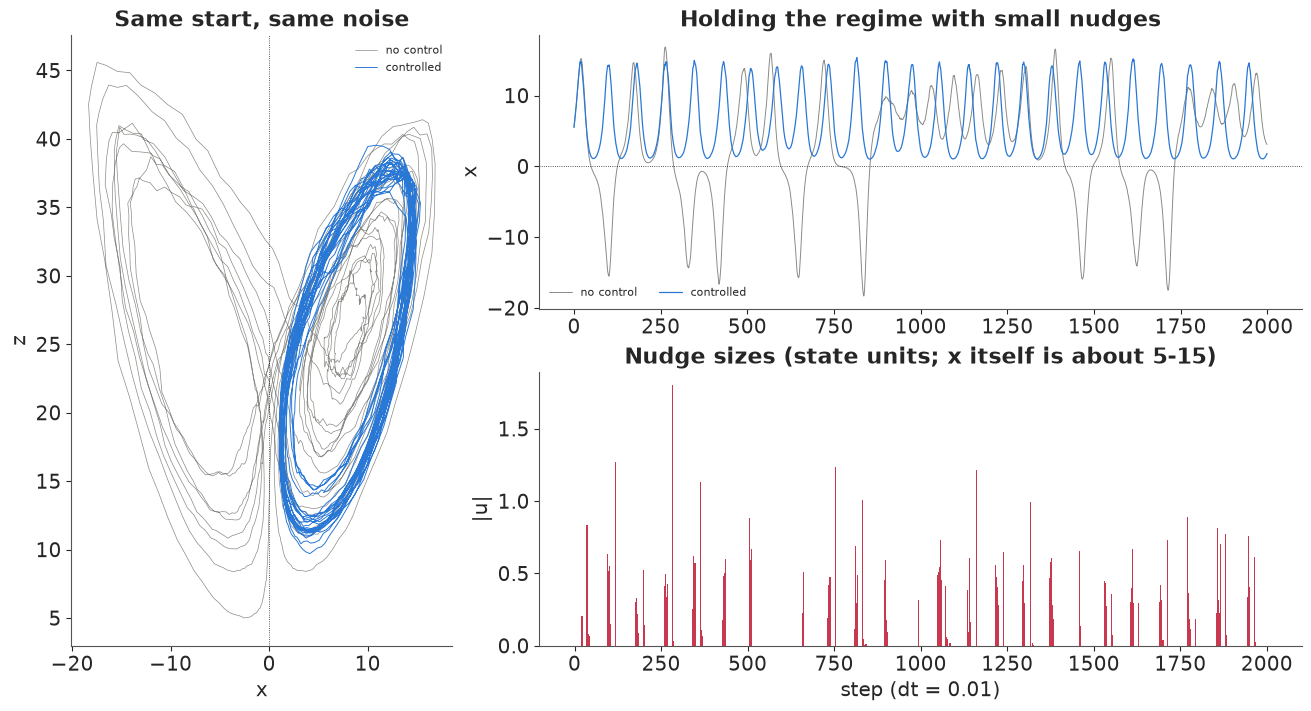

In [8]:
H_PLAN, X_MIN, N_MEMBERS = 30, 1.0, 20


def ensemble_forecast(s_ens, th_ens):
    """s_ens, th_ens: (R, E, 3). Paths of x (R, E, H) and sensitivities of x_h to s0 (R, E, H, 3)."""
    s = s_ens.copy()
    M = np.broadcast_to(np.eye(3), s.shape + (3,)).copy()
    xs, gs = [], []
    for _ in range(H_PLAN):
        M = M + DT * jacobian(s, th_ens) @ M
        s = rk4(s, th_ens)
        xs.append(s[..., 0])
        gs.append(M[..., 0, :])
    return np.stack(xs, -1), np.stack(gs, -2)


def plan_nudge(s_ens, th_ens, u_max, iters=3):
    """Smallest first-order nudge keeping the ensemble's 10% quantile of x above X_MIN (batched)."""
    R = s_ens.shape[0]
    u = np.zeros((R, 3))
    active = np.ones(R, bool)
    for _ in range(iters):
        xs, gs = ensemble_forecast(s_ens + u[:, None, :], th_ens)
        x_q = np.quantile(xs, 0.1, axis=1)                        # (R, H)
        h_star = np.argmin(x_q, axis=1)
        deficit = X_MIN - x_q[np.arange(R), h_star]
        need = active & (deficit > 0)
        if not need.any():
            break
        g = gs[np.arange(R), :, h_star].mean(axis=1)             # (R, 3)
        step = (1.1 * deficit / np.maximum((g * g).sum(1), 1e-12))[:, None] * g
        u = np.where(need[:, None], u + step, u)
        norm = np.linalg.norm(u, axis=1)
        over = norm > u_max
        u[over] *= (u_max / norm[over])[:, None]
        active &= ~over
    return u


def start_states(n, seed):
    """n independent starting points on the right wing of the attractor."""
    r = np.random.default_rng(seed)
    s = np.array([1.0, 1.0, 1.0]) + r.standard_normal((n, 3))
    for _ in range(600):
        s = rk4(s, THETA_TRUE)
    for _ in range(400):                                          # spread the phases, then wait
        s = np.where((r.random(n) < 0.5)[:, None], rk4(s, THETA_TRUE), s)
    while (s[:, 0] < 5).any():                                    # until each is well on the right
        s = np.where((s[:, 0] < 5)[:, None], rk4(s, THETA_TRUE), s)
    return s


def run_control(trigger, u_max=2.0, n_runs=20, steps=2000, obs_noise=0.0, state_ensemble=True,
                theta_ens=None, seed=0, lle_threshold=0.0, keep_path=False):
    """Simulate n_runs controlled trajectories in parallel; returns a dict of per-run results."""
    r = np.random.default_rng(seed)
    s = start_states(n_runs, seed)
    if theta_ens is None:
        theta_ens = np.broadcast_to(THETA_TRUE, (N_MEMBERS, 3))
    energy_u = np.zeros(n_runs)
    energy_x = np.zeros(n_runs)
    acted = np.zeros(n_runs, int)
    planned = np.zeros(n_runs, int)
    stayed = np.ones(n_runs, bool)
    record = []
    for t in range(steps):
        seen = s * (1 + obs_noise * r.standard_normal(s.shape))       # what the controller observes
        lle_now = local_lyapunov(seen)
        go = {"none": np.zeros(n_runs, bool), "lle": lle_now > lle_threshold,
              "geometric": seen[:, 0] < 4, "every step": np.ones(n_runs, bool)}[trigger]
        u = np.zeros((n_runs, 3))
        if go.any():
            idx = np.flatnonzero(go)
            members = theta_ens[r.integers(len(theta_ens), size=(len(idx), N_MEMBERS))]
            if obs_noise > 0 and state_ensemble:
                s_ens = seen[idx, None, :] / (1 + obs_noise * r.standard_normal((len(idx), N_MEMBERS, 3)))
            else:
                s_ens = np.repeat(seen[idx, None, :], N_MEMBERS, axis=1)
            u[idx] = plan_nudge(s_ens, members, u_max)
            planned[idx] += 1
        acted += np.any(u != 0, axis=1)
        s = rk4(s + u, THETA_TRUE)
        s = s + 0.01 * np.abs(s) * r.standard_normal(s.shape)
        energy_u += (u**2).sum(1)
        energy_x += (s**2).sum(1)
        stayed &= s[:, 0] > 0
        if keep_path:
            record.append((s[0].copy(), u[0].copy(), lle_now[0]))
    out = dict(stayed=stayed, acted=acted, planned=planned, energy_ratio=energy_u / energy_x)
    if keep_path:
        out["path"] = np.array([a for a, _, _ in record])
        out["u"] = np.array([b for _, b, _ in record])
        out["lle"] = np.array([c for _, _, c in record])
    return out


posterior_members = theta_post[rng.choice(len(theta_post), 400, replace=False)]
t0 = time.time()
demo = run_control("lle", n_runs=1, theta_ens=posterior_members, keep_path=True, seed=3)
free = run_control("none", n_runs=1, keep_path=True, seed=3)
print(f"demo: {time.time() - t0:.1f} s; stayed on the right wing: {bool(demo['stayed'][0])}; "
      f"nudges applied at {demo['acted'][0]} of 2000 steps (planned at {demo['planned'][0]}); "
      f"median nudge size {np.median(np.linalg.norm(demo['u'][demo['u'].any(1)], axis=1)):.3f}; "
      f"control energy / system energy {100 * demo['energy_ratio'][0]:.4f}%")

fig = plt.figure(figsize=(13, 7))
gs = fig.add_gridspec(2, 3)
ax = fig.add_subplot(gs[:, 0])
ax.plot(free["path"][:, 0], free["path"][:, 2], color=GREY, lw=0.5, label="no control")
ax.plot(demo["path"][:, 0], demo["path"][:, 2], color=BLUE, lw=0.7, label="controlled")
ax.axvline(0, color=INK, lw=0.6, ls=":")
ax.set(xlabel="x", ylabel="z", title="Same start, same noise")
ax.legend(fontsize=8)
ax = fig.add_subplot(gs[0, 1:])
ax.plot(free["path"][:, 0], color=GREY, lw=0.7, label="no control")
ax.plot(demo["path"][:, 0], color=BLUE, lw=0.9, label="controlled")
ax.axhline(0, color=INK, lw=0.6, ls=":")
ax.set(ylabel="x", title="Holding the regime with small nudges")
ax.legend(fontsize=8, ncols=2)
ax = fig.add_subplot(gs[1, 1:])
mag = np.linalg.norm(demo["u"], axis=1)
ax.bar(np.arange(len(mag)), mag, width=3, color=RED)
ax.set(xlabel="step (dt = 0.01)", ylabel="|u|", title="Nudge sizes (state units; x itself is about 5-15)");

The uncontrolled trajectory switches wings repeatedly; the controlled one never leaves the right
wing. The nudges are rare and small compared with the state (the energy ratio, the metric the
paper reports, is a tiny fraction of a per cent). Look at *when* they happen: in bursts, as the
trajectory approaches the inner edge of the wing, where a small displacement decides whether the
next loop goes left or right.

## 5 · What matters: trigger rules, budgets and uncertainty

A single run proves feasibility. To learn which ingredients matter we run 20 trials per setting
(different starting points and noise), for 2000 steps each, and record the share of trials that
stay on the right wing, how often the controller plans and acts, and the energy ratio. First,
the **trigger** that decides when to plan: the paper's instantaneous LLE above 0; a naive
**geometric** rule (plan when $x < 4$); planning at **every step**; and no control.

no control                         stayed    0%   planned      0   acted     0   energy 0.00000%


lle, |u| <= 2.0                    stayed  100%   planned   1707   acted   225   energy 0.00239%


geometric, |u| <= 2.0              stayed  100%   planned   1030   acted    90   energy 0.00819%


every step, |u| <= 2.0             stayed  100%   planned   2000   acted   251   energy 0.00201%


lle, |u| <= 0.5                    stayed  100%   planned   1704   acted   239   energy 0.00193%


...

geometric, |u| <= 0.2              stayed    0%   planned   1172   acted   619   energy 0.00165%


every step, |u| <= 0.2             stayed  100%   planned   2000   acted   395   energy 0.00091%


lle, |u| <= 0.1                    stayed    0%   planned   1792   acted  1186   energy 0.00077%


geometric, |u| <= 0.1              stayed    0%   planned   1801   acted  1706   energy 0.00104%


every step, |u| <= 0.1             stayed   15%   planned   2000   acted   964   energy 0.00064%
(113 s)


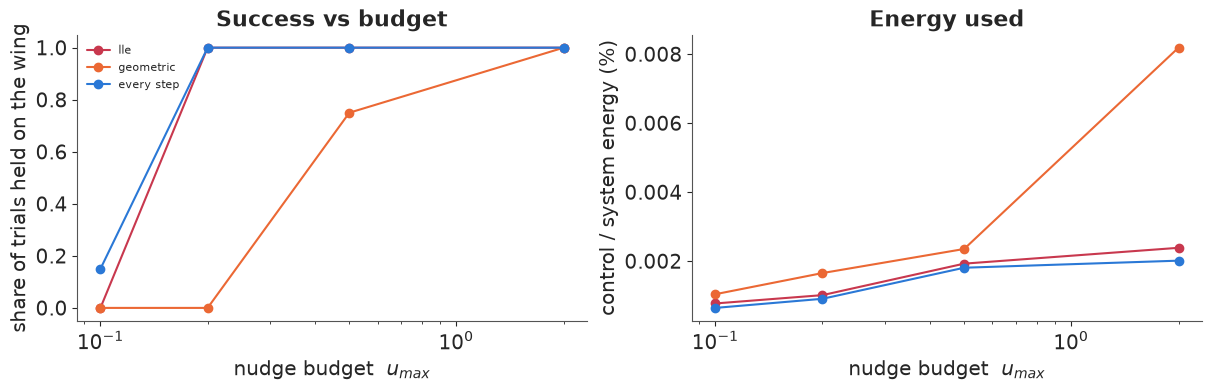

In [9]:
def table_row(name, res):
    return (f"{name:<34} stayed {res['stayed'].mean():5.0%}   planned {res['planned'].mean():6.0f}   "
            f"acted {res['acted'].mean():5.0f}   energy {100 * res['energy_ratio'].mean():.5f}%")


t0 = time.time()
budgets = [2.0, 0.5, 0.2, 0.1]
triggers = ["lle", "geometric", "every step"]
sweep = {}
print(table_row("no control", run_control("none", n_runs=20, seed=10)))
for u_max in budgets:
    for trig in triggers:
        sweep[trig, u_max] = run_control(trig, u_max=u_max, n_runs=20, seed=10,
                                         theta_ens=posterior_members)
        print(table_row(f"{trig}, |u| <= {u_max}", sweep[trig, u_max]))
print(f"({time.time() - t0:.0f} s)")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
for trig, c in zip(triggers, [RED, ORANGE, BLUE]):
    axes[0].plot(budgets, [sweep[trig, b]["stayed"].mean() for b in budgets], "o-", color=c, label=trig)
    axes[1].plot(budgets, [100 * sweep[trig, b]["energy_ratio"].mean() for b in budgets], "o-", color=c,
                 label=trig)
axes[0].set(xscale="log", xlabel="nudge budget  $u_{max}$", ylabel="share of trials held on the wing",
            ylim=(-0.05, 1.05), title="Success vs budget")
axes[1].set(xscale="log", xlabel="nudge budget  $u_{max}$", ylabel="control / system energy (%)",
            title="Energy used")
axes[0].legend(fontsize=8);

Read the table with the budget in mind.

- **With a generous budget ($u_{\max} = 2$) every trigger works**, and the differences are in
  cost. The LLE rule plans at 85% of steps (it fires whenever the local exponent is positive),
  so it saves little computation over planning every step, and it acts about as often, for a
  little more energy. The geometric rule plans least but reacts late: about four times the
  energy.
- **As the budget shrinks, timing decides.** The geometric rule is the first to fail (75% held
  at 0.5, none at 0.2): by the time $x < 4$ the allowed nudge is too small to change the outcome.
  At 0.2 the LLE rule and planning every step still hold every trial; at 0.1 everything fails,
  planning every step least often (15% held against none).
- So in this experiment the valuable ingredient is **the forecast-based planner**, which decides
  for itself whether a nudge is needed. The instantaneous-LLE trigger is a way of saving
  computation, and it is only safe when the budget leaves slack.

### Uncertainty in the state and in the model

Two more questions a Bayesian should ask. (1) If the controller sees the state with 5%
measurement error, should it plan from the observation as if it were exact, or from an ensemble
that represents the measurement error? (2) How much does it matter that the parameters were
learned? We compare planning with the posterior ensemble against planning with **prior** draws of
$(\sigma, \rho, \beta)$ - a controller that never saw the data.

In [10]:
t0 = time.time()
for noise in [0.02, 0.05]:
    for ens in [False, True]:
        res = run_control("every step", u_max=0.5, n_runs=20, seed=20, obs_noise=noise,
                          state_ensemble=ens, theta_ens=posterior_members)
        print(table_row(f"obs error {noise:.0%}, {'state ensemble' if ens else 'plug-in state'}", res))
prior_rng = np.random.default_rng(5)
prior_members = np.stack([np.exp(prior_rng.normal(np.log(m), 0.5, 400)) for m in (10, 30, 3)], axis=1)
for name, members in [("posterior parameter ensemble", posterior_members),
                      ("prior parameter ensemble", prior_members)]:
    print(table_row(name, run_control("every step", u_max=0.5, n_runs=20, seed=20,
                                      theta_ens=members)))
print(f"({time.time() - t0:.0f} s)")

obs error 2%, plug-in state        stayed  100%   planned   2000   acted   154   energy 0.00151%


obs error 2%, state ensemble       stayed  100%   planned   2000   acted   146   energy 0.00142%


obs error 5%, plug-in state        stayed  100%   planned   2000   acted   116   energy 0.00134%


obs error 5%, state ensemble       stayed  100%   planned   2000   acted    77   energy 0.00089%


posterior parameter ensemble       stayed  100%   planned   2000   acted   216   energy 0.00149%


prior parameter ensemble           stayed  100%   planned   2000   acted  1215   energy 0.02107%
(62 s)


- **Represent the measurement error.** Planning from the noisy observation as if it were exact
  makes the controller chase noise. With 5% error the state ensemble acts a third less often
  and uses a third less energy for the same success; with 2% error the difference is small.
  Nudges are applied only when the *distribution* of futures, not one noisy guess, is at risk.
- **Learn the model.** A controller that plans with prior-only parameters still holds the wing
  here - the budget of 0.5 leaves room to correct its mistakes - but it acts five times as often
  and spends more than ten times the energy, because its forecasts are wrong and it keeps
  correcting dangers that do not exist. Section 2's inference is what makes the nudges small.

## Summary

- Lorenz-63 is a two-regime system with irregular switching. The **instantaneous LLE** (largest
  eigenvalue of the symmetric Jacobian) marks where the flow is being stretched now; it is
  positive at most points of the attractor, negatively correlated with growth over the next
  half time unit, and high mainly on the route between the wings (section 1).
- **Chaos makes parameters easy and states hard.** Five noisy time units pin $\sigma, \rho,
  \beta$ to about half a per cent with a centred latent-state (multiple-shooting) model; the
  model-error scale is weakly identified and poorly sampled (section 2).
- **Forecasts are ensembles**, and their split between the wings is the window in which a
  controller must act (section 3).
- **Minimal-energy nudges** follow from the tangent propagator: required nudge = deficit /
  sensitivity, and chaos supplies the sensitivity (section 4).
- **What matters** in this rebuild of the weather jiu-jitsu experiment: a forecast-based planner
  that acts only when the ensemble is at risk; representing state uncertainty; learning the
  parameters. The LLE trigger mainly saves computation, and costs robustness when the nudge
  budget is tight (section 5).

## Try it yourself

1. **Observe only $x$.** Drop $y$ and $z$ from the likelihood in section 2. Are $\sigma, \rho,
   \beta$ still identified? How much wider is the posterior of the latent $z$, and how does the
   controller of section 5 cope when its ensemble is built from that posterior?
2. **The paper's goal.** Liu et al. confine the state to a box on one wing ($0 < x < 10$,
   $0 < y < 20$, $0 < z < 40$), which amounts to stabilising the trajectory near the wing's
   unstable fixed point $C^+ = (\sqrt{\beta(\rho - 1)}, \sqrt{\beta(\rho - 1)}, \rho - 1)$. Change
   the planner's constraint to the box and compare the energy with the wing-only goal.
3. **An optimal sequence.** Replace the one-step linear-response nudge by the paper's SLSQP
   optimisation of a nudge *sequence* over the horizon (scipy `minimize`, the ensemble objective
   vectorised). Is the energy lower? How much slower is it, and does it change the ranking of the
   trigger rules?